In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [2]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [3]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""

    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_l2_value(raw: str) -> bool | int | float | str:
    if raw == "true":
        return True
    if raw == "false":
        return False
    if re.fullmatch(r"\d+", raw):
        return int(raw)
    if re.fullmatch(r"\d+\.\d+", raw):
        return float(raw)
    return raw

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [4]:
def generate_df(roots_gen: callable) -> pd.DataFrame:
    dfs = []

    for workload in WORKLOADS:
        records: list[dict] = []
        for label, (kernel, root) in roots_gen(workload).items():
            for path in sorted(root.glob("*.time")):
                if "train" in path.name:
                    continue
                metrics = parse_time_file(path)
                try:
                    log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
                except FileNotFoundError:
                    log_metrics = {}

                m = re.search(
                    r"^(?P<mib>\d+)MiB_run(?P<run>\d+)_(?P<model>[^_]+)_discounted_reward_(?P<discounted_reward>\d+)_(?P<workload>.+)_l2-(?P<l2>[^_]+)_(?P<hist_length>\d+)_(?P<penalty>[0-9]+(?:\.[0-9]+)?)(?:\.time)?$",
                    path.name,
                )
                parsed = {}
                if m:
                    l2_value = parse_l2_value(m.group("l2"))
                    parsed = {
                        "MiB": int(m.group("mib")),
                        "run": int(m.group("run")),
                        "model": m.group("model"),
                        "filename_workload": m.group("workload"),
                        "discounted_reward": int(m.group("discounted_reward")),
                        "l2": l2_value,
                        "minmax": l2_value if isinstance(l2_value, bool) else None,
                        "hist_length": int(m.group("hist_length")),
                        "penalty": float(m.group("penalty")),
                    }

                records.append({
                    "policy": label,
                    "kernel": kernel,
                    "file": path.name,
                    "MiB": extract_mib(path),
                    "run": extract_run(path),
                    **metrics,
                    **log_metrics,
                    **parsed,
                })

        df = pd.DataFrame(records)
        df["workload"] = workload

        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
    
def plot_df(df: pd.DataFrame):

    policy_order = list(dict.fromkeys(df["policy_penalty"]))
    policy_palette = dict(zip(policy_order, sns.color_palette(n_colors=len(policy_order))))

    def minmax_interval(values):
        return values.min(), values.max()

    for workload_group in df.groupby("workload"):
        print(workload_group[0])
        plt.figure(figsize=(14, 8))
        ax = sns.barplot(
            workload_group[1],
            x="MiB",
            y="real",
            hue="policy_penalty",
            hue_order=policy_order,
            palette=policy_palette,
            estimator="mean",
            errorbar=minmax_interval,
        )
        ax.set(title=workload_group[0], xlabel="Memory Footprint (MiB)", ylabel="Execution Time (s)")

        for container in ax.containers:
            labels = [f"{value:.2f}" if pd.notna(value) else "" for value in container.datavalues]
            ax.bar_label(container, labels=labels, padding=3, fontsize=9)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.08)

        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        plt.tight_layout()
        plt.show()

In [6]:
roots_6_18 = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/arms/{workload}")),
        "model 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/model/{workload}")),
    }

df = generate_df(roots_6_18)

In [7]:
df_plot = df[df["MiB"].isin([4009, 4028, 6009, 8009, 8028, 10009, 10028])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)

DuckDB-TPCH-sf100


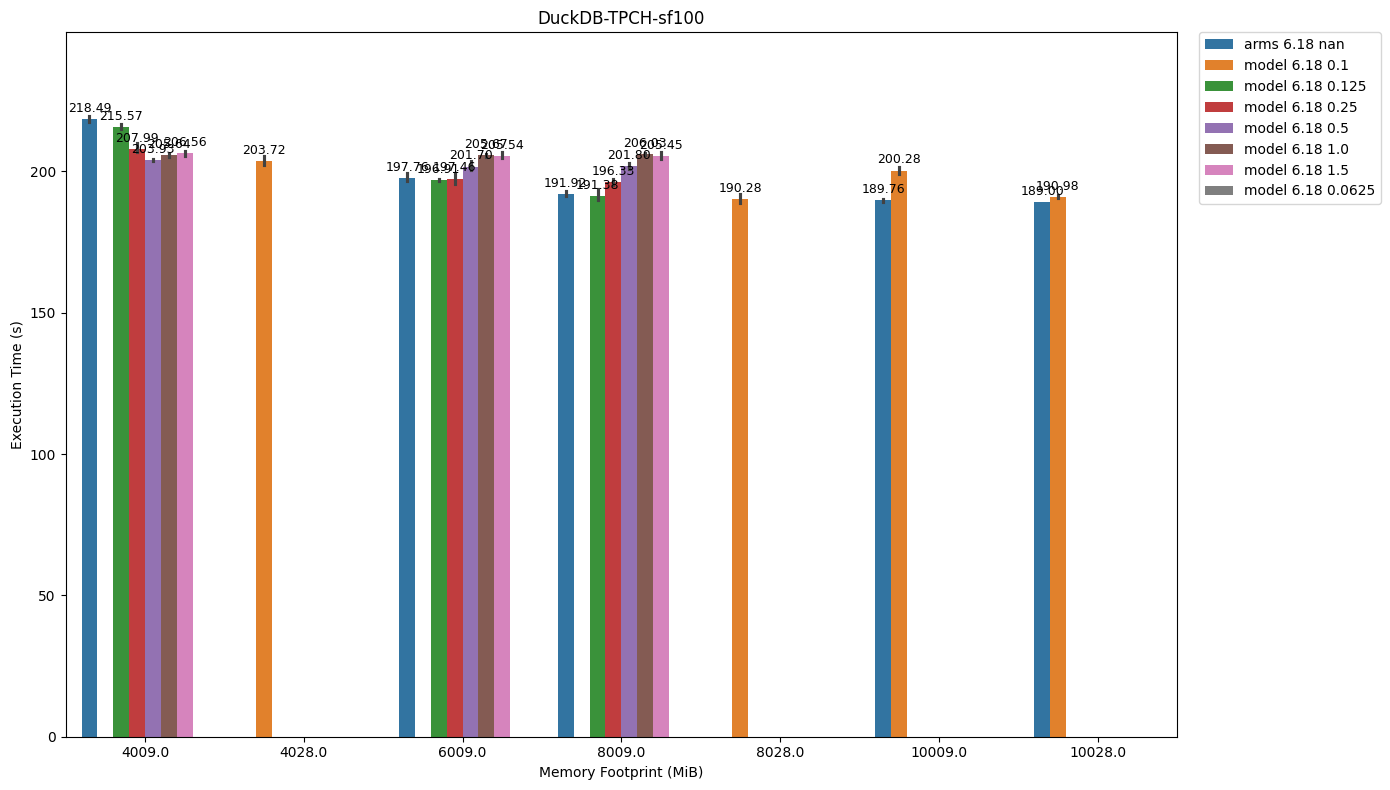

XSBench


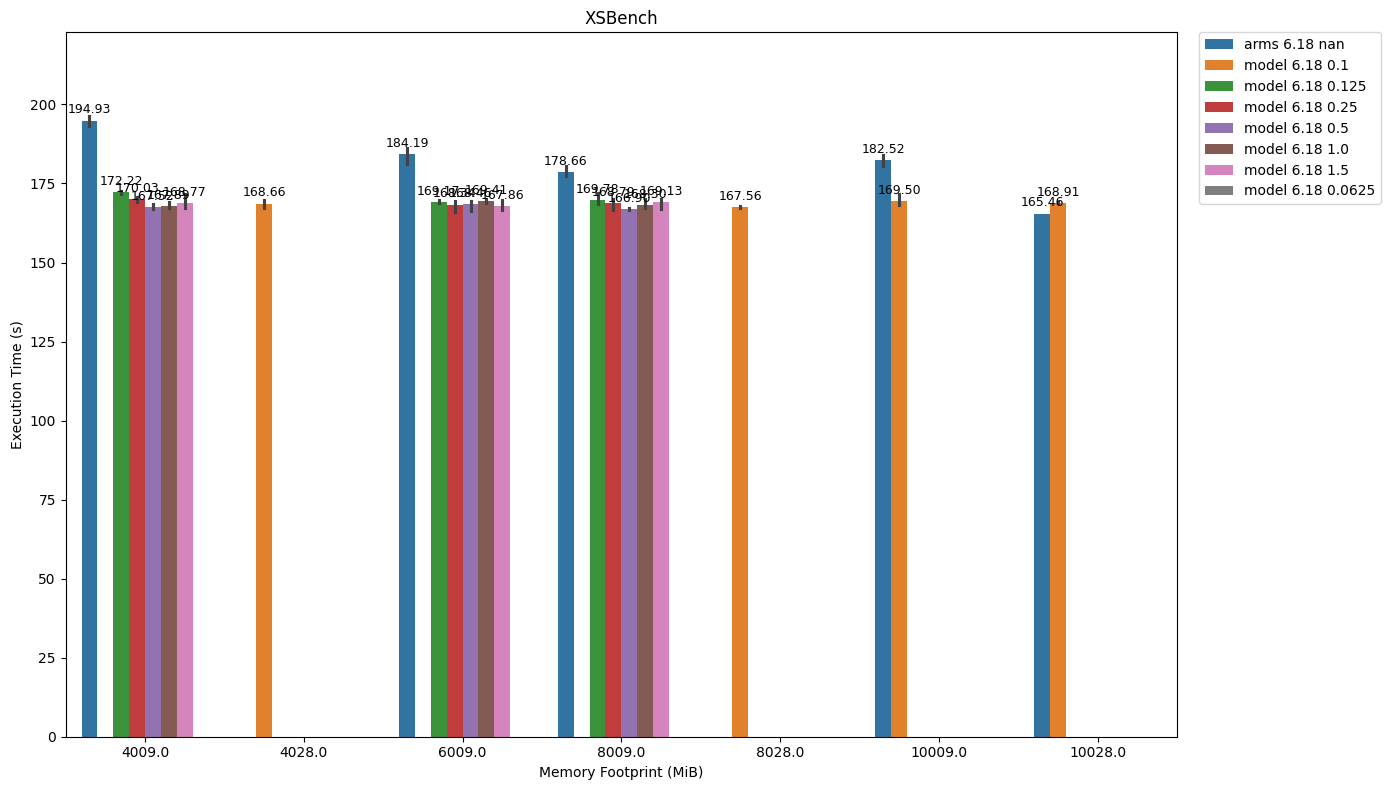

bc-kron.sg


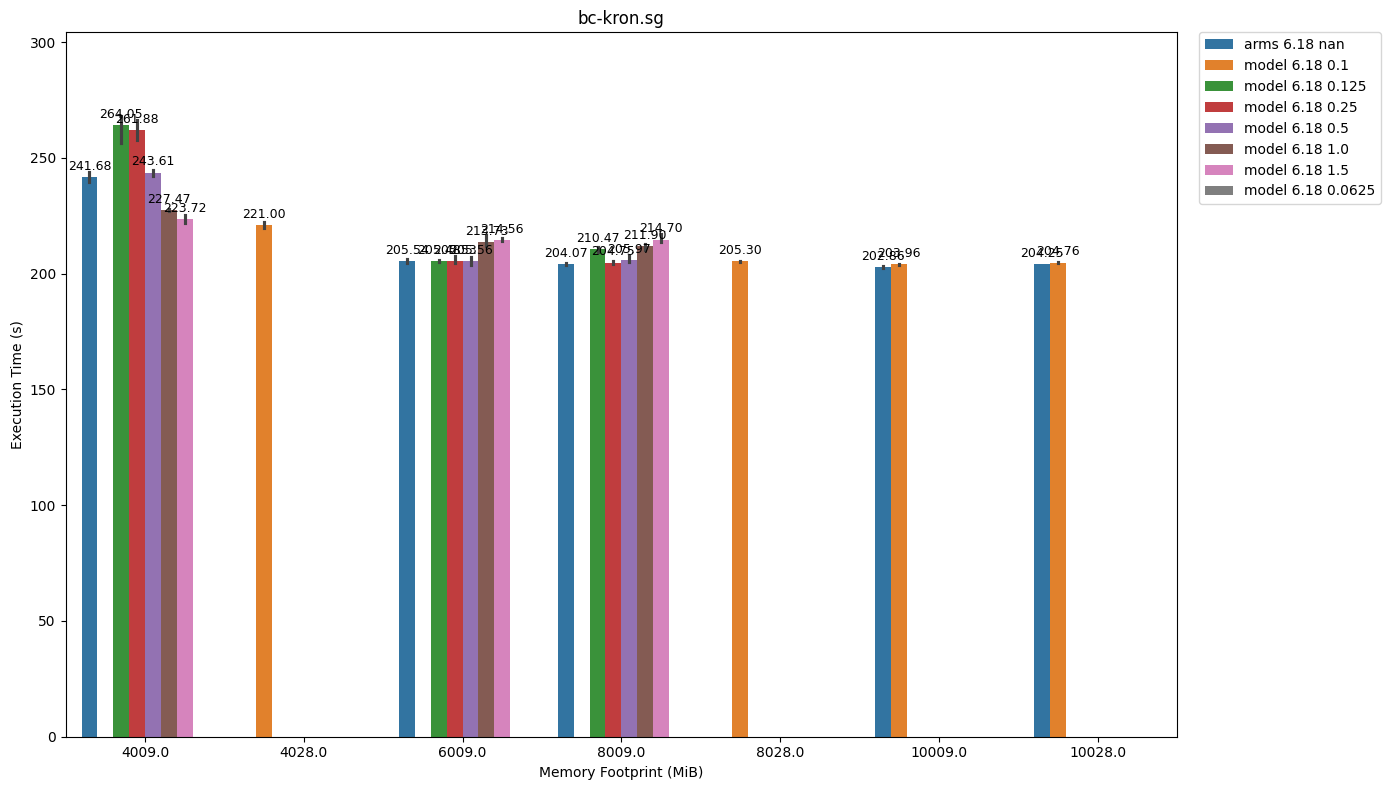

bc-twitter.sg


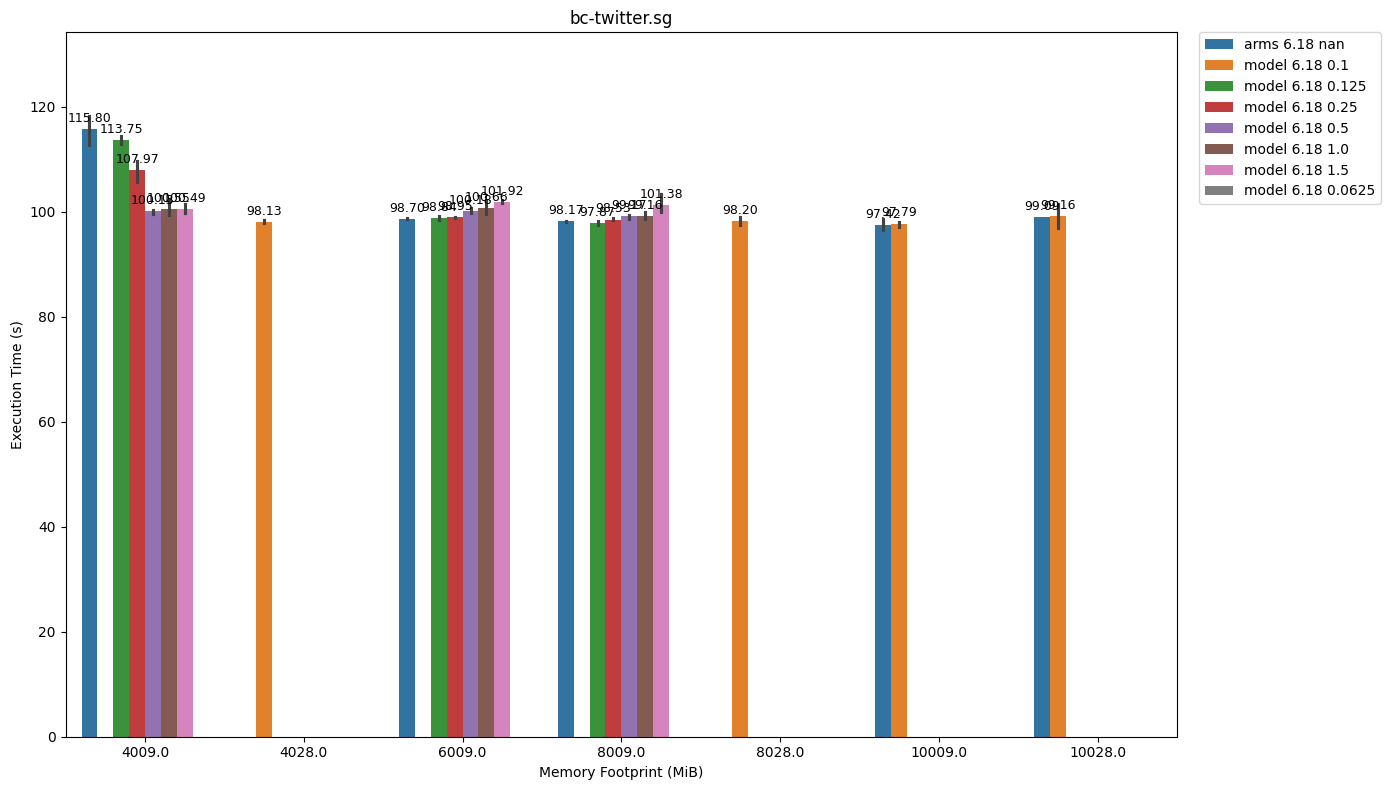

faiss_10M


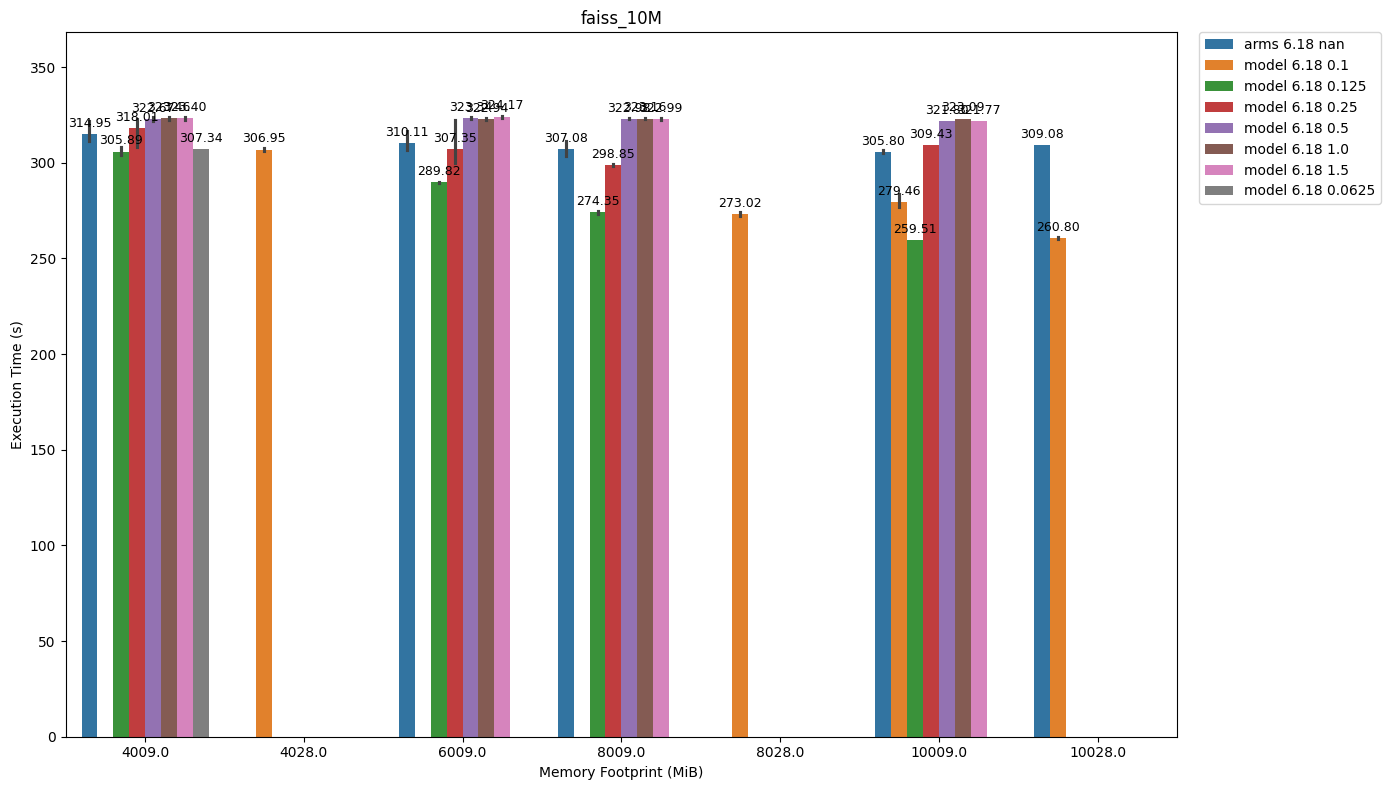

mg.D.x


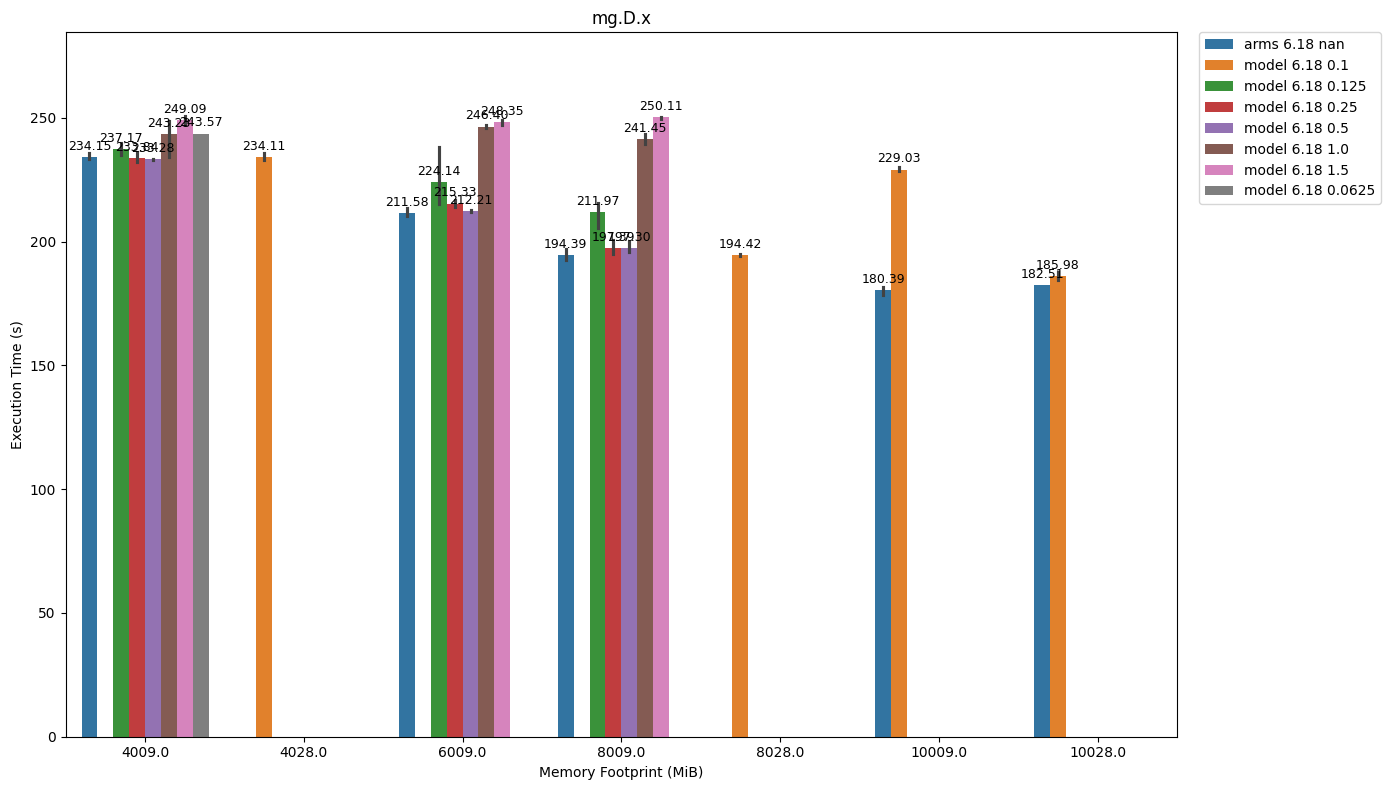

pr-kron.sg


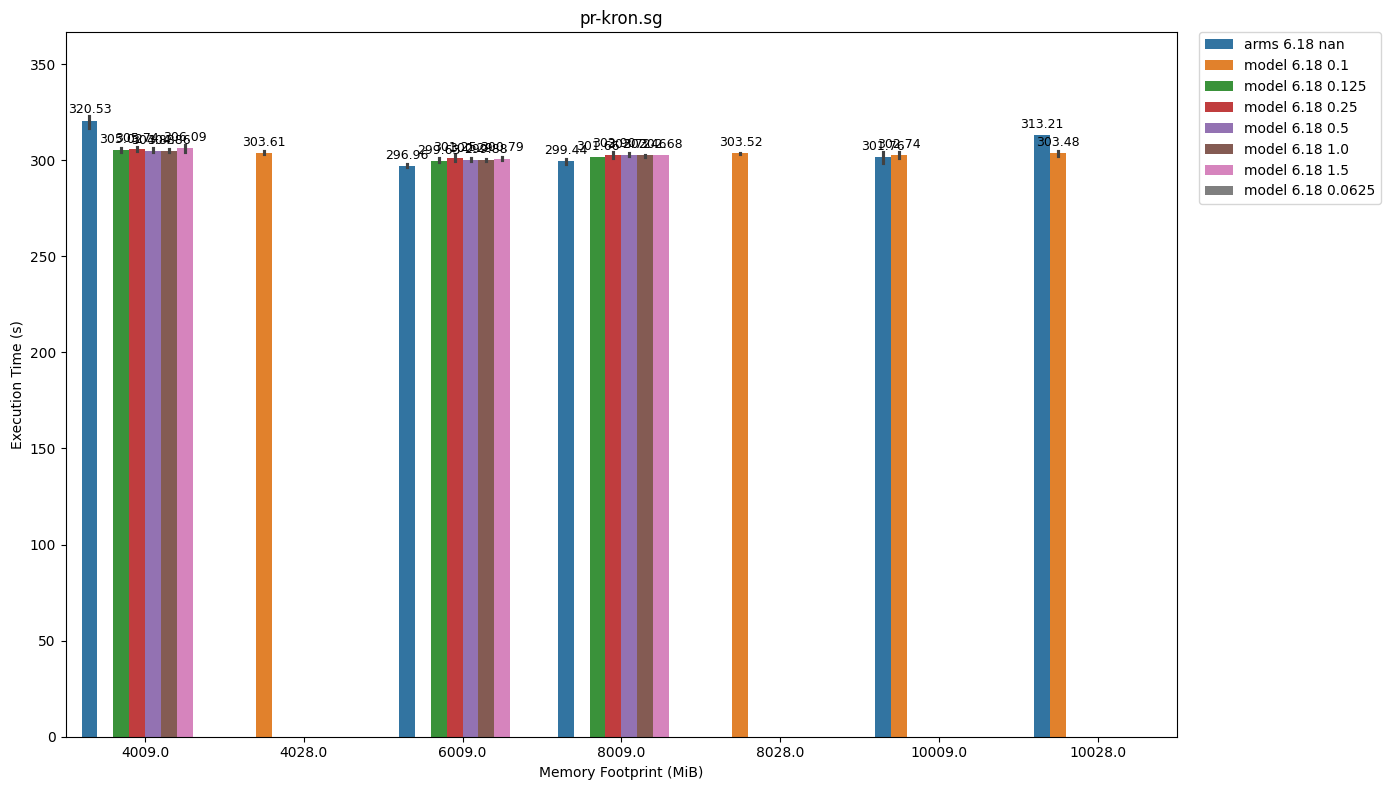

pr-twitter.sg


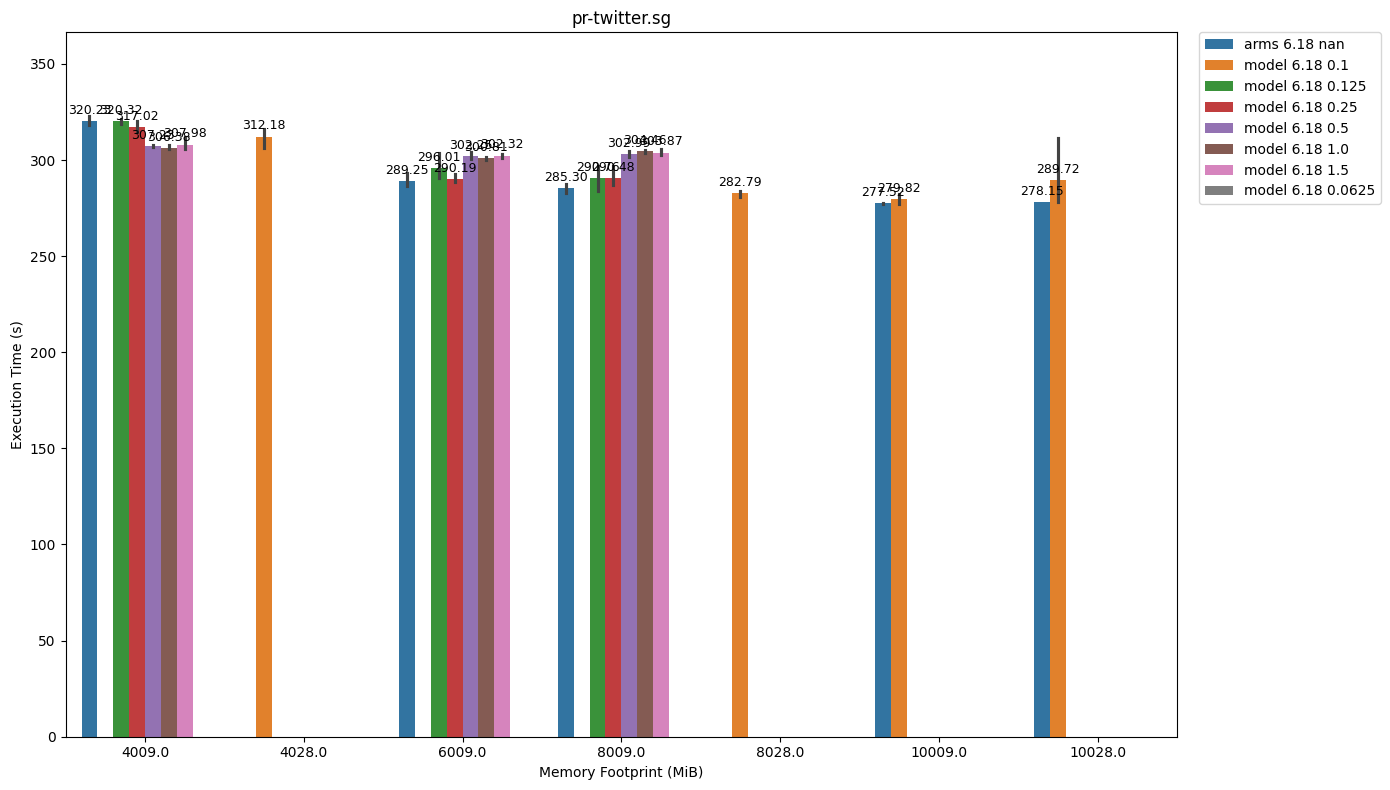

In [8]:
plot_df(df_plot)

In [9]:
models = pd.DataFrame([
    {
        "name": "bc-kron.sg",
        "R2": 0.94,
        "MAE": 14.4,
        "RMSE": 68.83
    },
    {
        "name": "pr-kron.sg",
        "R2": 0.94,
        "MAE": 12.3,
        "RMSE": 125.98
    },
    {
        "name": "bc-twitter.sg",
        "R2": 0.86,
        "MAE": 20.6,
        "RMSE": 132.25
    },
    {
        "name": "pr-twitter.sg",
        "R2": 0.996,
        "MAE": 6.12,
        "RMSE": 58.08
    },
    {
        "name": "faiss_10M",
        "R2": 0.52,
        "MAE": 20.32,
        "RMSE": 445.114
    },
    {
        "name": "mg.D.x",
        "R2": 0.89,
        "MAE": 14.76,
        "RMSE": 382.47
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "R2": 0.85,
        "MAE": 374.43,
        "RMSE": 2725.63
    },{
        "name": "XSBench",
        "R2": 0.91,
        "MAE": 12.66,
        "RMSE": 422.32
    }
])

runs = pd.DataFrame([
    {
        "name": "bc-kron.sg",
        "size": 2,
        "accesses": 150,
        "best scaler": 3.5,
        "weight": 1 
    },
    {
        "name": "bc-kron.sg",
        "size": 4,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-kron.sg",
        "size": 6,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-kron.sg",
        "size": 8,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-twitter.sg",
        "size": 2,
        "accesses": 15,
        "best scaler": .7, 
        "weight": 1
    },
    {
        "name": "bc-twitter.sg",
        "size": 4,
        "accesses": 8,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "bc-twitter.sg",
        "size": 6,
        "accesses": 5,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "bc-twitter.sg",
        "size": 8,
        "accesses": 3,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "pr-kron.sg",
        "size": 2,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 4,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 6,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 8,
        "accesses": 3,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-twitter.sg",
        "size": 2,
        "accesses": 13,
        "best scaler": 1.0, 
        "weight": 1
    },
    {
        "name": "pr-twitter.sg",
        "size": 4,
        "accesses": 10,
        "best scaler": 0.2,
        "weight": 2
    },
    {
        "name": "pr-twitter.sg",
        "size": 6,
        "accesses": 8,
        "best scaler": 0.2,
        "weight": 2
    },
    {
        "name": "pr-twitter.sg",
        "size": 8,
        "accesses": 0,
        "best scaler": 0.0625, 
        "weight": 2
    },
    {
        "name": "mg.D.x",
        "size": 2,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 4,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 6,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 8,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 2,
        "accesses": 350,
        "best scaler": 6.0,
        "weight": 1 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 4,
        "accesses": 150,
        "best scaler": 0.5,
        "weight": 2 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 6,
        "accesses": 150,
        "best scaler": 0.5,
        "weight": 2 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 8,
        "accesses": 100,
        "best scaler": 0.5,
        "weight": 2  
    },
    {
        "name": "XSBench",
        "size": 2,
        "accesses": 0.8,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 4,
        "accesses": 0.7,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 6,
        "accesses": 0.7,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 8,
        "accesses": 0.7,
        "best scaler": 0.5,
        "weight": 0.25
    },
    {
        "name": "faiss_10M",
        "size": 2,
        "accesses": 2.7,
        "best scaler": 0.125,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 4,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 6,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 8,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2 
    },
])

In [10]:
from sklearn.linear_model import LinearRegression

# Merge the dataframes
merged_df = runs.merge(models, on="name", how="left")

# Create and train the linear model
features = ["accesses"]
X = merged_df[features]
y = merged_df["best scaler"]
sample_weight = merged_df["weight"]

model = LinearRegression()
model.fit(X, y, sample_weight=sample_weight)

for feature in features:
    print(f"Coefficient for {feature}: {model.coef_[features.index(feature)]:.4f}")
print(f"Model intercept: {model.intercept_:.4f}")
print(f"R² score: {model.score(X, y, sample_weight=sample_weight):.4f}")

Coefficient for accesses: 0.0114
Model intercept: 0.0936
R² score: 0.6246


In [11]:
merged_df["hand calculated"] = 0.01 * merged_df["accesses"] + .1

In [12]:
merged_df["predicted_best_scaler"] = model.predict(X)
merged_df

,name,size,accesses,best scaler,weight,R2,MAE,RMSE,hand calculated,predicted_best_scaler
0,bc-kron.sg,2,150.00,3.500000,1.00,0.940,14.40,68.830,1.6000,1.806820
1,bc-kron.sg,4,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
2,bc-kron.sg,6,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
3,bc-kron.sg,8,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
4,bc-twitter.sg,2,15.00,0.700000,1.00,0.860,20.60,132.250,0.2500,0.264901
5,bc-twitter.sg,4,8.00,0.200000,2.00,0.860,20.60,132.250,0.1800,0.184950
6,bc-twitter.sg,6,5.00,0.200000,2.00,0.860,20.60,132.250,0.1500,0.150685
7,bc-twitter.sg,8,3.00,0.200000,2.00,0.860,20.60,132.250,0.1300,0.127842
8,pr-kron.sg,2,2.25,0.500000,0.20,0.940,12.30,125.980,0.1225,0.119276
9,pr-kron.sg,4,2.25,0.500000,0.20,0.940,12.30,125.980,0.1225,0.119276


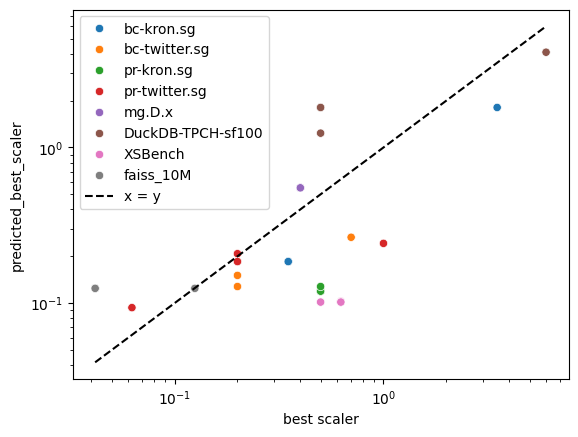

In [13]:

sns.scatterplot(merged_df, x="best scaler", y="predicted_best_scaler", hue="name")
plt.xscale("log")
plt.yscale("log")
ax = plt.gca()
min_val = min(merged_df["best scaler"].min(), merged_df["predicted_best_scaler"].min())
max_val = max(merged_df["best scaler"].max(), merged_df["predicted_best_scaler"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", label="x = y")
ax.legend()
plt.show()